In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

In [2]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

startdate = '2019-11-01'
enddate = '2019-12-31'

datastream1 = 'sgpmergedsmpsapsE13.c1'
datastream2 = 'sgpacsmcdceE13.c2'
datastream3 = 'sgpaoppsap1flynn1mE13.c1'
datastream4 = 'sgpaosmetE13.a1'
datastream5 = 'sgpceil10mC1.b1'
datastream6 = 'sgpaosccn2colaavgE13.b1'

result_datastream1_met = act.discovery.download_arm_data(arm_username, arm_token, datastream1, startdate, enddate)
result_datastream2_met = act.discovery.download_arm_data(arm_username, arm_token, datastream2, startdate, enddate)
result_datastream3_met = act.discovery.download_arm_data(arm_username, arm_token, datastream3, startdate, enddate)
result_datastream4_met = act.discovery.download_arm_data(arm_username, arm_token, datastream4, startdate, enddate)
result_datastream5_met = act.discovery.download_arm_data(arm_username, arm_token, datastream5, startdate, enddate)
result_datastream6_met = act.discovery.download_arm_data(arm_username, arm_token, datastream6, startdate, enddate)

Enter ARM username:  abhigyan
Enter ARM token (hidden):  ········


[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191101.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191102.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191103.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191104.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191105.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191106.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191107.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191108.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191109.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191110.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191111.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191112.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191113.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191114.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191115.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191116.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191117.000000.nc
[DOWNLOADING] sgpmergedsmpsapsE13.c1.20191118.00

In [3]:
df1 = act.io.read_arm_netcdf(result_datastream1_met)
df2 = act.io.read_arm_netcdf(result_datastream2_met)
df3 = act.io.read_arm_netcdf(result_datastream3_met)
df4 = act.io.read_arm_netcdf(result_datastream4_met)
df5 = act.io.read_arm_netcdf(result_datastream5_met)
df6 = act.io.read_arm_netcdf(result_datastream6_met)

In [4]:
print(df1.sizes,"\n", df2.sizes,"\n", df3.sizes,"\n", df4.sizes,"\n", df5.sizes,"\n", df6.sizes)

Frozen({'time': 1464, 'bound': 2, 'merged_diameter_mobility': 212, 'diameter_aerodynamic': 52, 'diameter_mobility': 192}) 
 Frozen({'time': 6051, 'bound': 2}) 
 Frozen({'time': 86400, 'bound': 2}) 
 Frozen({'time': 5177123}) 
 Frozen({'time': 323546, 'bound': 2, 'range': 770}) 
 Frozen({'time': 5577, 'bound': 2, 'droplet_size': 20, 'setpoint': 6})


In [5]:
print(df1.time,"\n", df2.time,"\n", df3.time,"\n", df4.time,"\n", df5.time,"\n", df5.time)

<xarray.DataArray 'time' (time: 1464)> Size: 12kB
array(['2019-11-01T00:00:00.000000000', '2019-11-01T01:00:00.000000000',
       '2019-11-01T02:00:00.000000000', ..., '2019-12-31T21:00:00.000000000',
       '2019-12-31T22:00:00.000000000', '2019-12-31T23:00:00.000000000'],
      shape=(1464,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 12kB 2019-11-01 ... 2019-12-31T23:00:00
Attributes:
    long_name:      Time offset from midnight
    bounds:         time_bounds
    standard_name:  time 
 <xarray.DataArray 'time' (time: 6051)> Size: 48kB
array(['2019-11-01T00:07:41.000000000', '2019-11-01T00:17:58.000000000',
       '2019-11-01T00:28:16.000000000', ..., '2019-12-30T22:31:16.000000000',
       '2019-12-30T23:01:07.000000000', '2019-12-30T23:31:39.000000000'],
      shape=(6051,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 48kB 2019-11-01T00:07:41 ... 2019-12-30T23...
Attributes:
    long_name:      Time offset from midnight
   

In [6]:
print(df1.time.diff("time")[:5],"\n",df2.time.diff("time")[:5],"\n",df3.time.diff("time")[:5],"\n",df4.time.diff("time")[:5],"\n",df5.time.diff("time")[:5],"\n",df6.time.diff("time")[:5])

<xarray.DataArray 'time' (time: 5)> Size: 40B
array([3600000000000, 3600000000000, 3600000000000, 3600000000000,
       3600000000000], dtype='timedelta64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2019-11-01T01:00:00 ... 2019-11-01T05:...
Attributes:
    long_name:      Time offset from midnight
    bounds:         time_bounds
    standard_name:  time 
 <xarray.DataArray 'time' (time: 5)> Size: 40B
array([617000000000, 618000000000, 617000000000, 617000000000,
       618000000000], dtype='timedelta64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2019-11-01T00:17:58 ... 2019-11-01T00:...
Attributes:
    long_name:      Time offset from midnight
    bounds:         time_bounds
    standard_name:  time 
 <xarray.DataArray 'time' (time: 5)> Size: 40B
array([60000000000, 60000000000, 60000000000, 60000000000, 60000000000],
      dtype='timedelta64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2019-11-01T00:01:30 ... 2019-11-01T00:...
Attributes:
    l

In [7]:
print(df1.data_vars,"\n", df2.data_vars,"\n", df3.data_vars,"\n", df4.data_vars,"\n", df5.data_vars,"\n", df6.data_vars)

Data variables:
    base_time                            (time) datetime64[ns] 12kB 2019-11-0...
    time_offset                          (time) datetime64[ns] 12kB 2019-11-0...
    time_bounds                          (time, bound) object 23kB dask.array<chunksize=(24, 2), meta=np.ndarray>
    merged_diameter_mobility_bounds      (time, merged_diameter_mobility, bound) float64 5MB dask.array<chunksize=(24, 212, 2), meta=np.ndarray>
    diameter_aerodynamic_bounds          (time, diameter_aerodynamic, bound) float32 609kB dask.array<chunksize=(24, 52, 2), meta=np.ndarray>
    diameter_mobility_bounds             (time, diameter_mobility, bound) float32 2MB dask.array<chunksize=(24, 192, 2), meta=np.ndarray>
    effective_density                    (time) float32 6kB dask.array<chunksize=(24,), meta=np.ndarray>
    qc_effective_density                 (time) int32 6kB dask.array<chunksize=(24,), meta=np.ndarray>
    effective_density_solution_strength  (time) float64 12kB dask.array<chu

In [8]:
df6["supersaturation_calculated"].to_series().describe()

count    5577.000000
mean        0.382399
std         0.283492
min         0.086439
25%         0.189530
50%         0.385248
75%         0.792618
max         1.034438
Name: supersaturation_calculated, dtype: float64

# Preprocessing

In [ ]:
"""
Prepare machine-learning dataframe for CCN prediction.
"""

# =============================================================================
# Select variables
# =============================================================================
df1_dist = df1[["merged_dN_dlogDp"]]
df2_vars = df2[["nitrate_CDCE", "sulfate_CDCE", "ammonium_CDCE"]]
df3_vars = df3[["Ba_G_combined", "Bs_G", "AAE_BR", "AE_BR"]]
df4_vars = df4[["rh_ambient", "temperature_ambient"]]
df6_vars = df6[["N_CCN"]]

# =============================================================================
# Apply QC filtering
# =============================================================================
df1_dist["merged_dN_dlogDp"] = df1_dist["merged_dN_dlogDp"].where(df1["qc_merged_dN_dlogDp"] == 0)
df2_vars["nitrate_CDCE"] = df2_vars["nitrate_CDCE"].where(df2["qc_nitrate_CDCE"] == 0)
df2_vars["sulfate_CDCE"] = df2_vars["sulfate_CDCE"].where(df2["qc_sulfate_CDCE"] == 0)
df2_vars["ammonium_CDCE"] = df2_vars["ammonium_CDCE"].where(df2["qc_ammonium_CDCE"] == 0)
df3_vars["Bs_G"] = df3_vars["Bs_G"].where(df3["qc_Bs_G"] == 0)
df3_vars["Ba_G_combined"] = df3_vars["Ba_G_combined"].where(df3["qc_Ba_G_combined"] == 0)
df3_vars["AAE_BR"] = df3_vars["AAE_BR"].where(df3["qc_AAE_BR"] == 0)
df3_vars["AE_BR"] = df3_vars["AE_BR"].where(df3["qc_AE_BR"] == 0)
df6_vars["N_CCN"] = df6_vars["N_CCN"].where(df6["qc_N_CCN"] == 0)

# =============================================================================
# Reduce aerosol size distribution
# =============================================================================
diam = df1["merged_diameter_mobility"]
dN_small = df1_dist["merged_dN_dlogDp"][:, diam < 80].sum(dim="merged_diameter_mobility")
dN_medium = df1_dist["merged_dN_dlogDp"][:, (diam >= 80) & (diam < 200)].sum(dim="merged_diameter_mobility")
dN_large = df1_dist["merged_dN_dlogDp"][:, diam >= 200].sum(dim="merged_diameter_mobility")
df1_reduced = xr.Dataset({"dN_small": dN_small, "dN_medium": dN_medium, "dN_large": dN_large})

# =============================================================================
# Add bulk aerosol variables
# =============================================================================
df1_bulk = df1[["merged_total_SA_conc", "merged_total_V_conc", "effective_density"]]
df1_bulk["merged_total_SA_conc"] = df1_bulk["merged_total_SA_conc"].where(df1["qc_merged_total_SA_conc"] == 0)
df1_bulk["merged_total_V_conc"] = df1_bulk["merged_total_V_conc"].where(df1["qc_merged_total_V_conc"] == 0)
df1_bulk["effective_density"] = df1_bulk["effective_density"].where(df1["qc_effective_density"] == 0)

# =============================================================================
# Final aerosol dataset
# =============================================================================
df1_vars = xr.merge([df1_reduced, df1_bulk])

# =============================================================================
# Resample to common 10-minute resolution
# =============================================================================
df1_10m = df1_vars.resample(time="10min").nearest()
df2_10m = df2_vars.resample(time="10min").nearest()
df3_10m = df3_vars.resample(time="10min").mean()
df4_10m = df4_vars.resample(time="10min").mean()
df6_10m = df6_vars.resample(time="10min").mean()

# =============================================================================
# Merge datasets
# =============================================================================
combined = xr.merge([df1_10m, df2_10m, df3_10m, df4_10m, df6_10m])

# =============================================================================
# Convert to dataframe
# =============================================================================
df_ml = combined.to_dataframe().reset_index()

# =============================================================================
# Check missing values
# =============================================================================
print("\nMissing fraction:\n")
print(df_ml.isnull().mean())

# =============================================================================
# Remove missing values
# =============================================================================
df_ml = df_ml.dropna()

# =============================================================================
# Remove unnecessary columns
# =============================================================================
drop_cols = ["lat", "lon", "alt", "bound"]
for col in drop_cols:
    if col in df_ml.columns: 
        df_ml = df_ml.drop(columns=col)

# =============================================================================
# Final dataframe check
# =============================================================================
print("\nFinal dataframe shape:\n")
print(df_ml.shape)
print("\nFirst few rows:\n")
print(df_ml.head())

/tmp/ipykernel_5935/3452497034.py:61: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.merge([df1_10m, df2_10m, df3_10m, df4_10m, df6_10m])


In [ ]:
df_ml.to_csv("/data/home/abhigyan/total_smokeshow/data/data.csv")

# EDA and Machine Learning

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

In [11]:
df_ml = pd.read_csv("/data/home/abhigyan/total_smokeshow/data/data.csv")

In [12]:
df_ml.columns

Index(['Unnamed: 0', 'time', 'dN_small', 'dN_medium', 'dN_large',
       'merged_total_SA_conc', 'merged_total_V_conc', 'effective_density',
       'nitrate_CDCE', 'sulfate_CDCE', 'ammonium_CDCE', 'Ba_G_combined',
       'Bs_G', 'AAE_BR', 'AE_BR', 'rh_ambient', 'temperature_ambient',
       'N_CCN'],
      dtype='str')

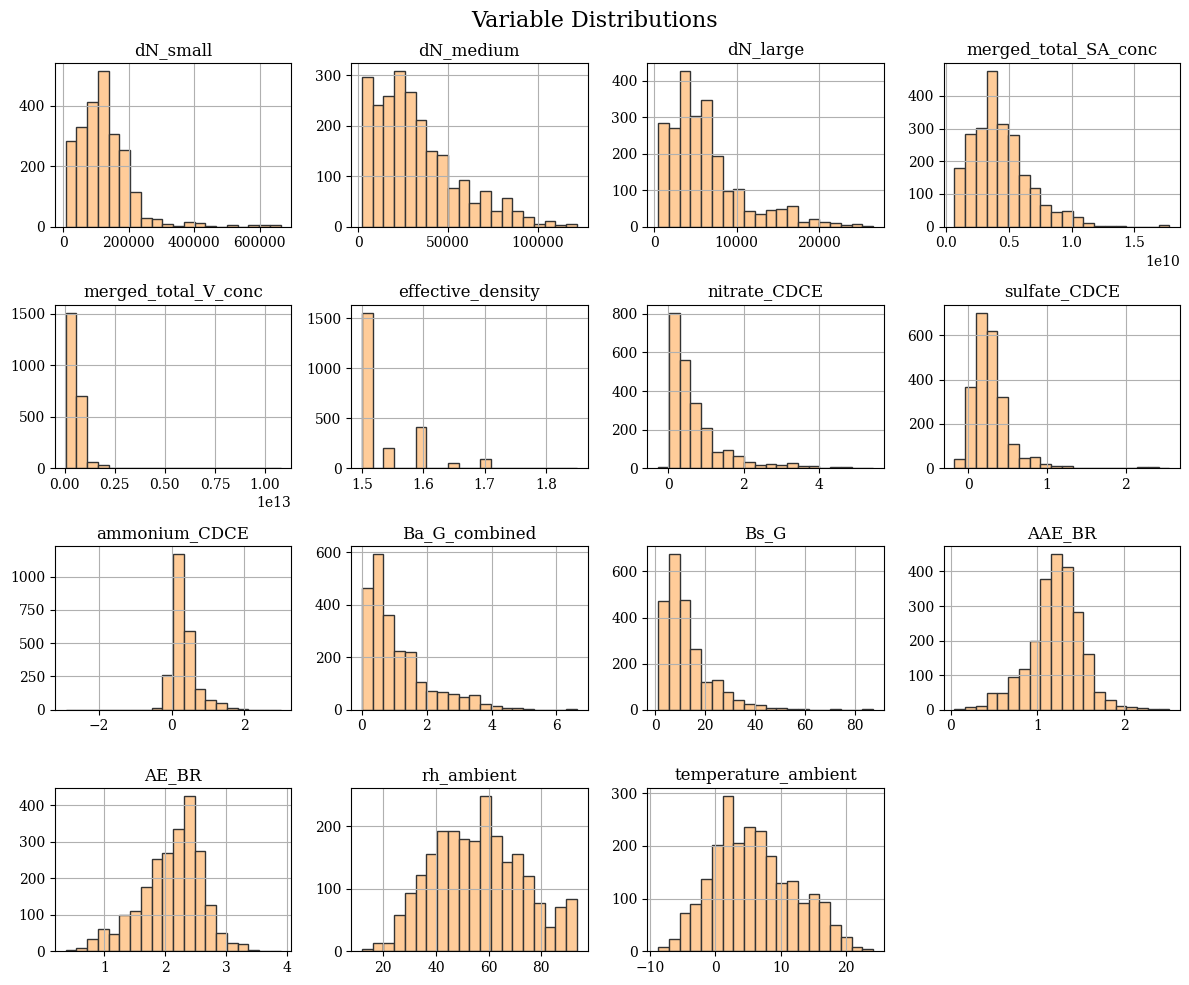

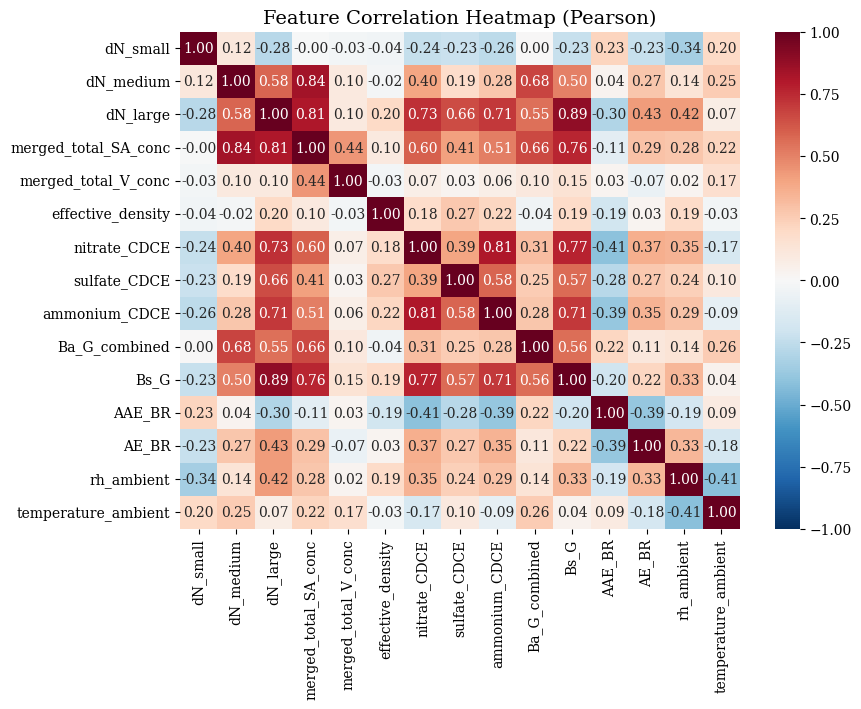

<Figure size 800x500 with 0 Axes>

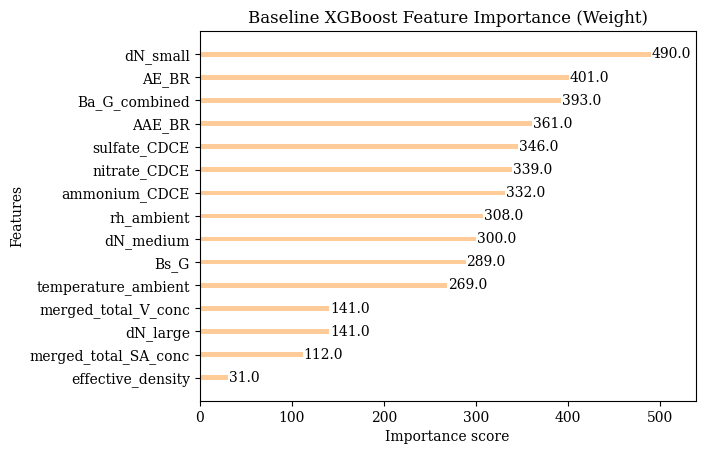

In [13]:
# --- Global Visual Settings ---
plt.rcParams['font.family'] = 'serif'
PRIMARY_COLOR = '#FFCC99'  # Pastel Orange
SECONDARY_COLOR = '#333333' # Professional Black/Grey

"""
SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
Visualizing distributions and correlations to understand data quality.
"""

# 2.1 Histograms of all variables
df_hist = df_ml.drop(columns=['Unnamed: 0','N_CCN', 'time'])
df_hist.hist(bins=20, figsize=(12, 10), color=PRIMARY_COLOR, edgecolor=SECONDARY_COLOR)
plt.suptitle('Variable Distributions', fontsize=16)
plt.tight_layout()
plt.savefig("/data/home/abhigyan/total_smokeshow/Results/Histogram.png")
plt.show()


# 2.2 Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))
df_corr = df_ml.drop(columns=['Unnamed: 0','N_CCN', 'time'])
corr = df_corr.corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='RdBu_r', fmt=".2f", cbar=True)
plt.title('Feature Correlation Heatmap (Pearson)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.9])
plt.savefig("/data/home/abhigyan/total_smokeshow/Results/Correlation.png")
plt.show()


# 2.3 Baseline XGBoost Importance
# Quick baseline feature importance check

X_base = df_ml.drop(['Unnamed: 0', 'N_CCN', 'time'], axis=1)
y_base = df_ml['N_CCN']

temp_model = xgb.XGBRegressor(
    random_state=41
)

temp_model.fit(X_base, y_base)

plt.figure(figsize=(8, 5))

xgb.plot_importance(
    temp_model,
    color=PRIMARY_COLOR,
    grid=False,
    importance_type='weight'
)

plt.title('Baseline XGBoost Feature Importance (Weight)')

plt.savefig(
    "/data/home/abhigyan/total_smokeshow/Results/Feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}

Model Performance:
R2 Score: 0.210
RMSE: 639.965


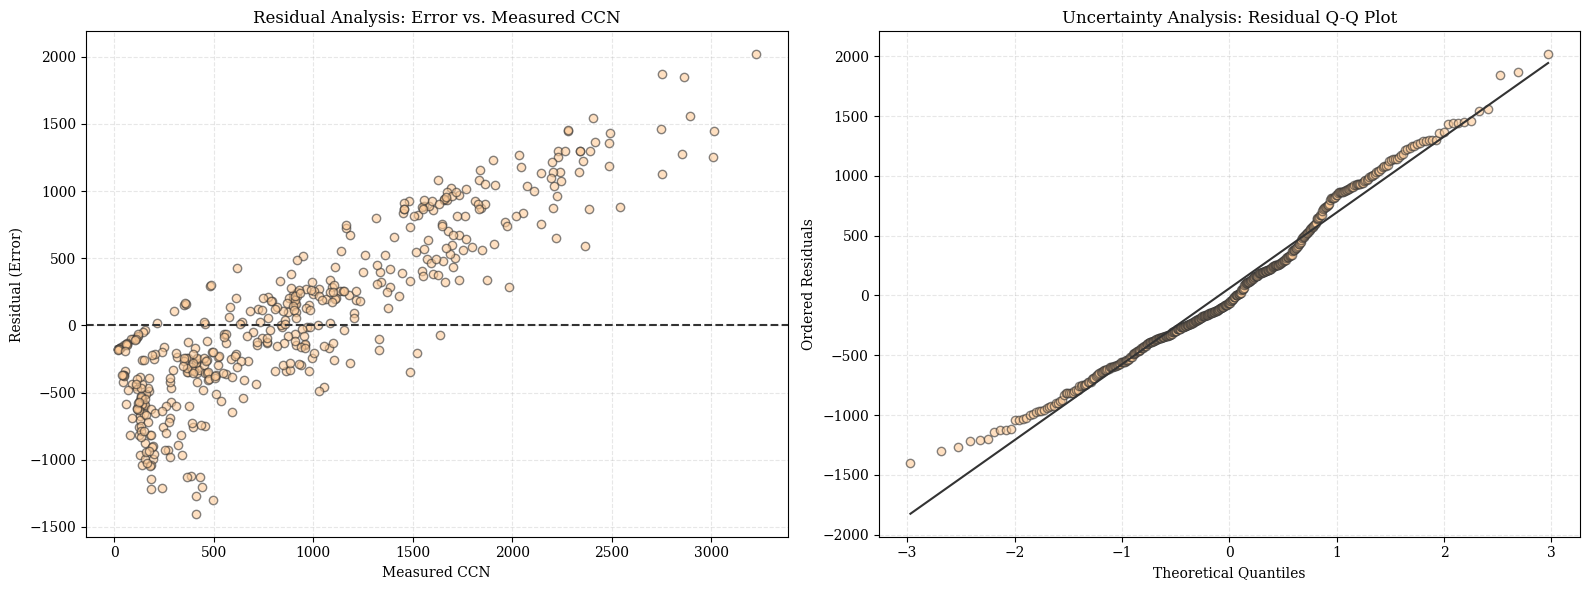

In [14]:
"""
SECTION 3: ML MODELLING
Handling the time-series split, hyperparameter tuning, training,
and uncertainty analysis.
"""

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =============================================================================
# 3.0 Data Preparation
# =============================================================================

df_mask = df_ml.drop(
    [
        'Unnamed: 0',
        'time',
        "merged_total_SA_conc",
        "merged_total_V_conc",
        "dN_large",
       # "Bs_G",
       # "ammonium_CDCE",
        "effective_density"
    ],
    axis=1
)

# =============================================================================
# 3.1 Time-Sequential Split (80% Train, 20% Test)
# =============================================================================

split_idx = int(len(df_mask) * 0.8)

train_df = df_mask.iloc[:split_idx]
test_df  = df_mask.iloc[split_idx:]

X_train = train_df.drop('N_CCN', axis=1)
y_train = train_df['N_CCN']

X_test = test_df.drop('N_CCN', axis=1)
y_test = test_df['N_CCN']

# =============================================================================
# 3.2 Hyperparameter Tuning with TimeSeriesSplit
# =============================================================================

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# =============================================================================
# 3.3 Best Model
# =============================================================================

model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# =============================================================================
# 3.4 Performance Metrics
# =============================================================================

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\nModel Performance:")
print(f"R2 Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# =============================================================================
# 3.5 Uncertainty Analysis
# =============================================================================

residuals = y_test - preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Residual Plot
ax1.scatter(
    y_test,
    residuals,
    color=PRIMARY_COLOR,
    alpha=0.6,
    edgecolors=SECONDARY_COLOR
)

ax1.axhline(0, color=SECONDARY_COLOR, linestyle='--')

ax1.set_xlabel('Measured CCN')
ax1.set_ylabel('Residual (Error)')
ax1.set_title('Residual Analysis: Error vs. Measured CCN')

ax1.grid(True, linestyle='--', alpha=0.3)

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=ax2)

ax2.get_lines()[0].set_markerfacecolor(PRIMARY_COLOR)
ax2.get_lines()[0].set_markeredgecolor(SECONDARY_COLOR)
ax2.get_lines()[0].set_alpha(0.6)

ax2.get_lines()[1].set_color(SECONDARY_COLOR)

ax2.set_title('Uncertainty Analysis: Residual Q-Q Plot')

ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Ordered Residuals')

ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/data/home/abhigyan/total_smokeshow/Results/Residual.png"
)

plt.show()

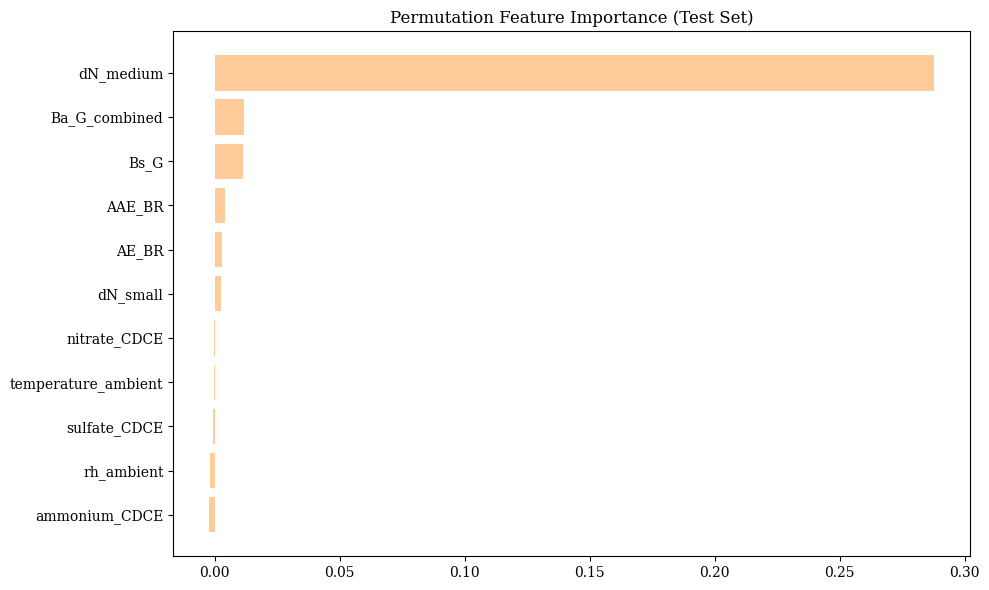

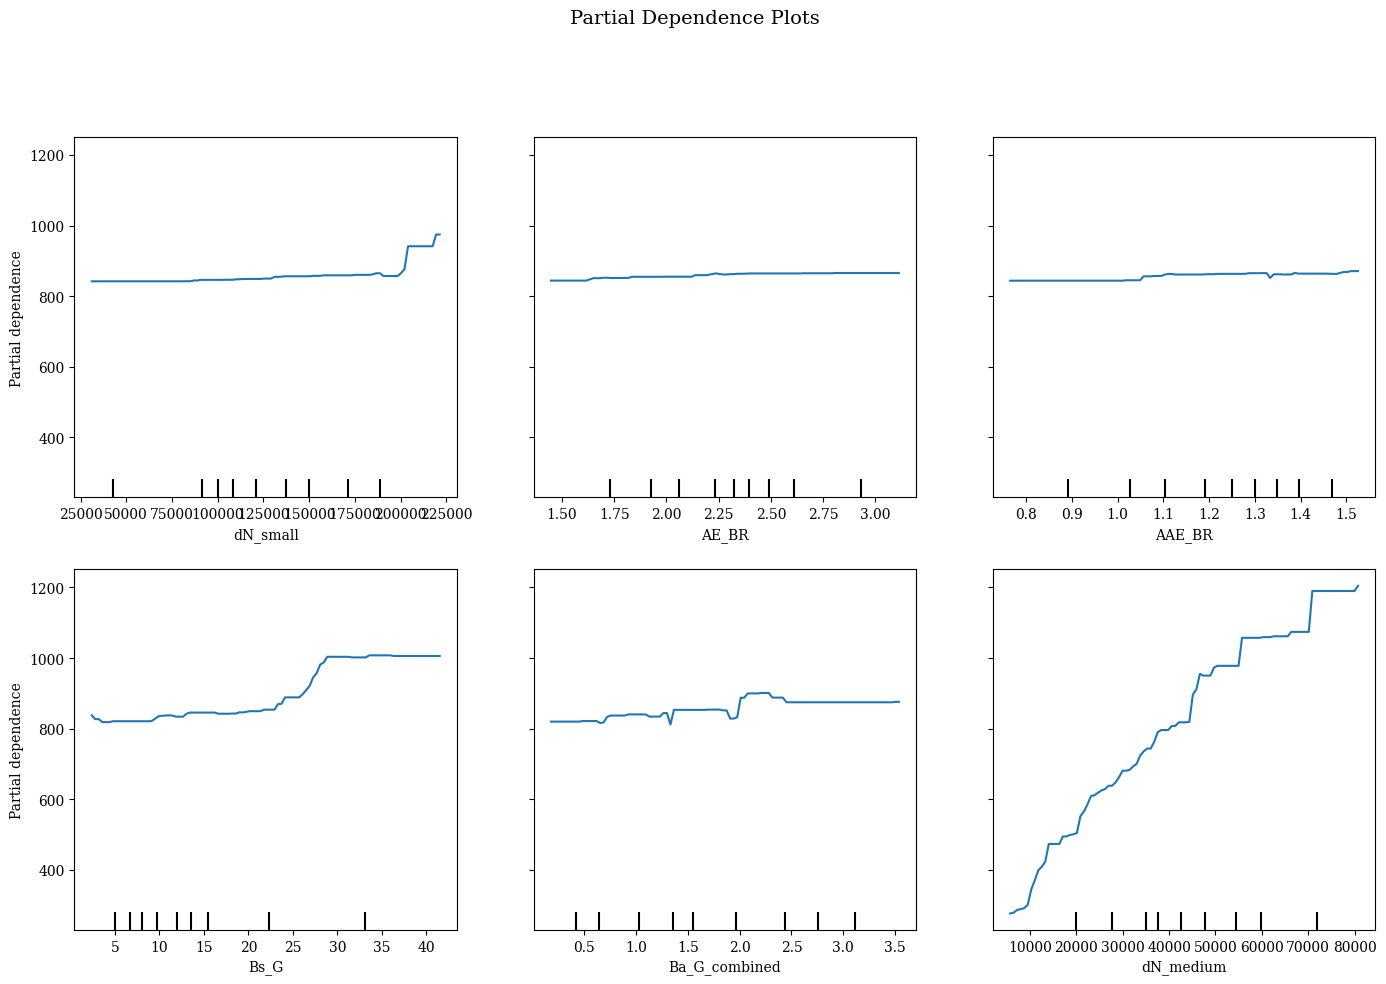

In [17]:
"""
SECTION 4: EXPLAINABLE AI (XAI)
Interpreting the model using SHAP, Permutation Importance, and PDPs.
"""

# 4.1 Permutation Feature Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 6))  # wider figure
plt.barh(X_test.columns[sorted_idx], perm_importance.importances_mean[sorted_idx], color=PRIMARY_COLOR)
plt.title("Permutation Feature Importance (Test Set)")
plt.tight_layout()  # auto-adjusts margins to fit labels
plt.savefig("/data/home/abhigyan/total_smokeshow/Results/PFI.png", bbox_inches='tight')  # key fix
plt.show()

# 4.2 Partial Dependence Plots (PDP)
top_features = X_test.columns[sorted_idx][-6:]
fig, ax = plt.subplots(figsize=(14, 10))  # larger figure
PartialDependenceDisplay.from_estimator(model, X_test, top_features, ax=ax)
plt.suptitle('Partial Dependence Plots', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(
    "/data/home/abhigyan/total_smokeshow/Results/PDP.png",
    bbox_inches='tight',   # key fix
    pad_inches=0.3         # adds padding around the figure
)
plt.show()

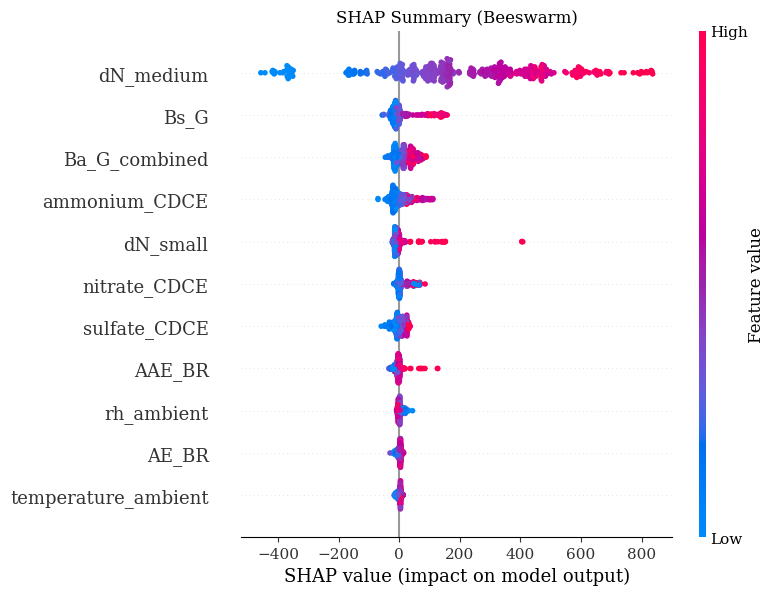

<Figure size 800x600 with 0 Axes>

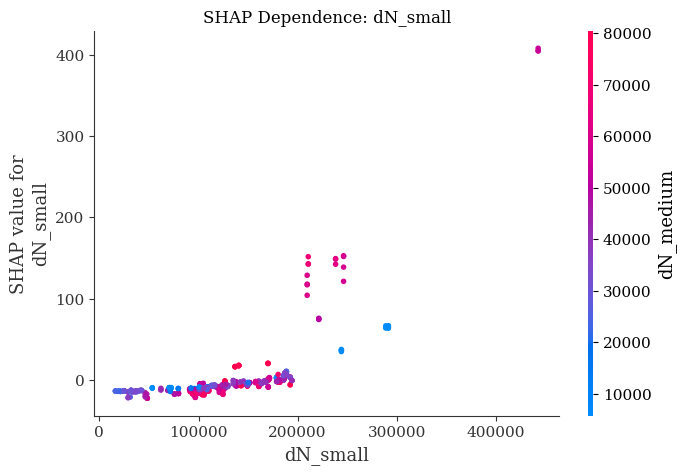

<Figure size 800x600 with 0 Axes>

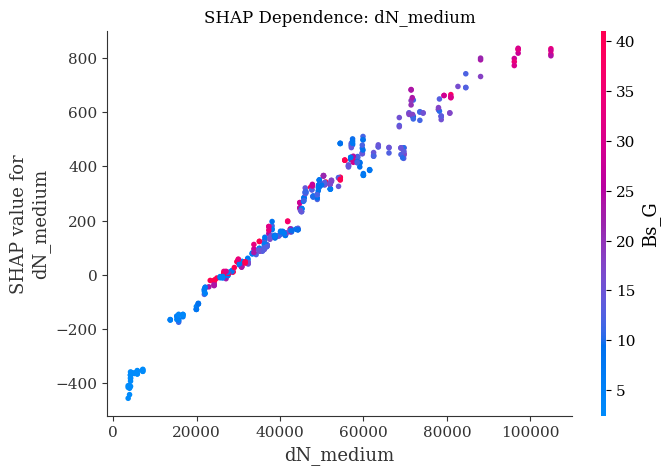

<Figure size 800x600 with 0 Axes>

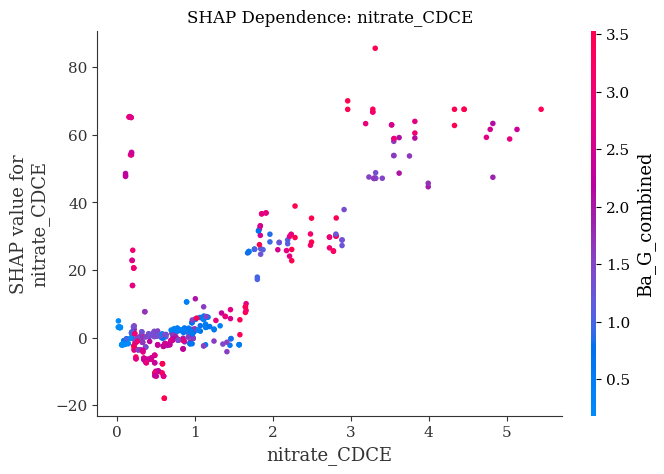

<Figure size 800x600 with 0 Axes>

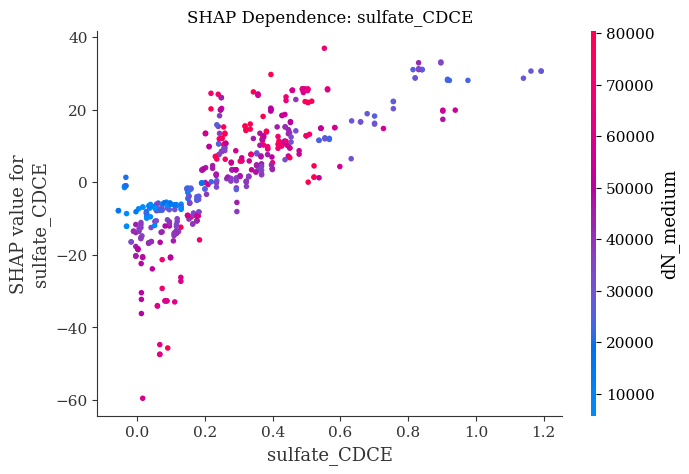

<Figure size 800x600 with 0 Axes>

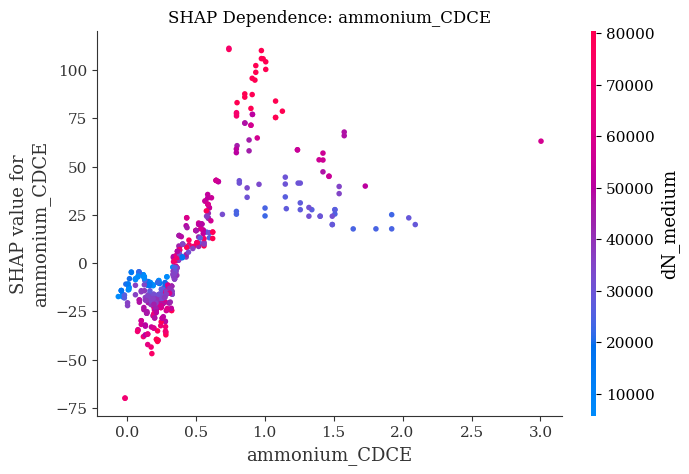

<Figure size 800x600 with 0 Axes>

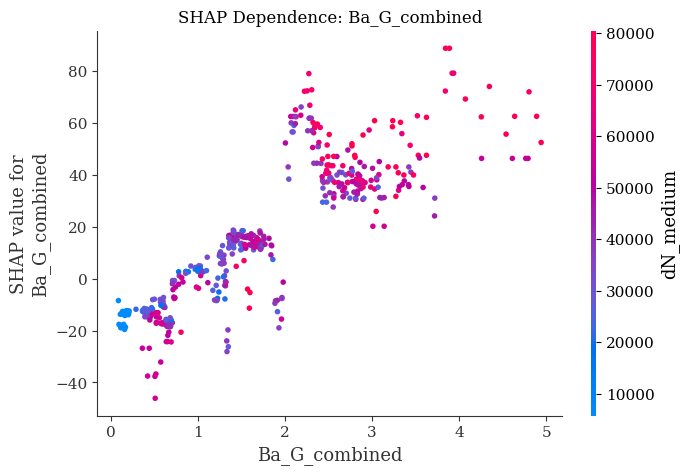

<Figure size 800x600 with 0 Axes>

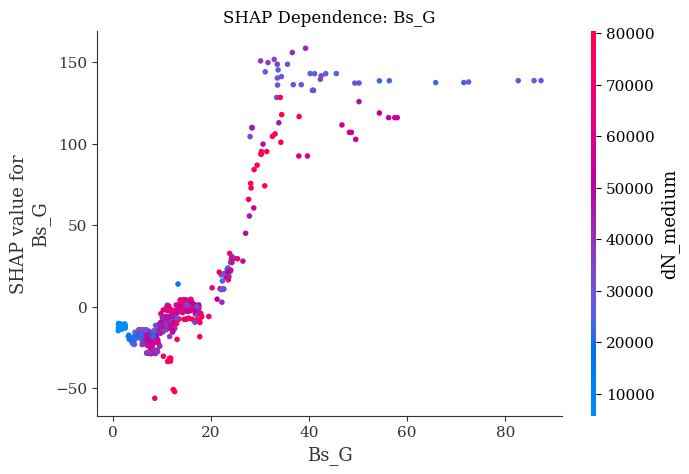

<Figure size 800x600 with 0 Axes>

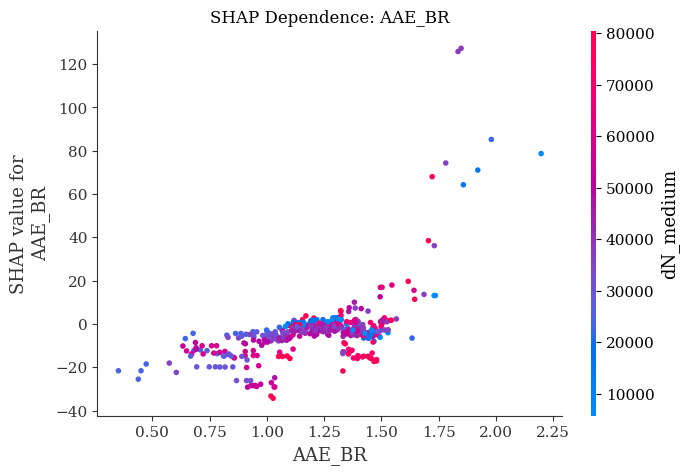

<Figure size 800x600 with 0 Axes>

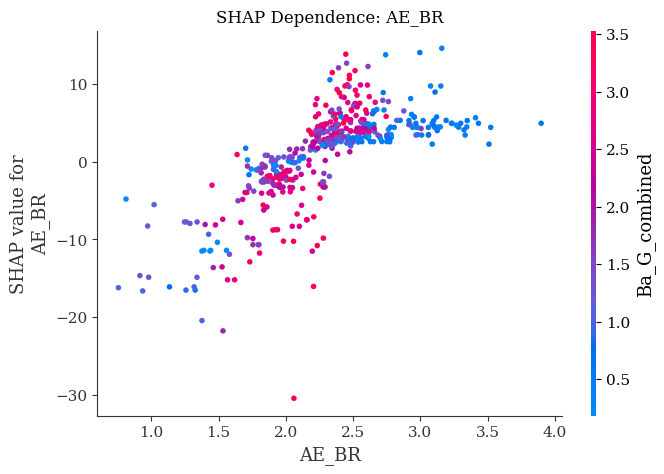

<Figure size 800x600 with 0 Axes>

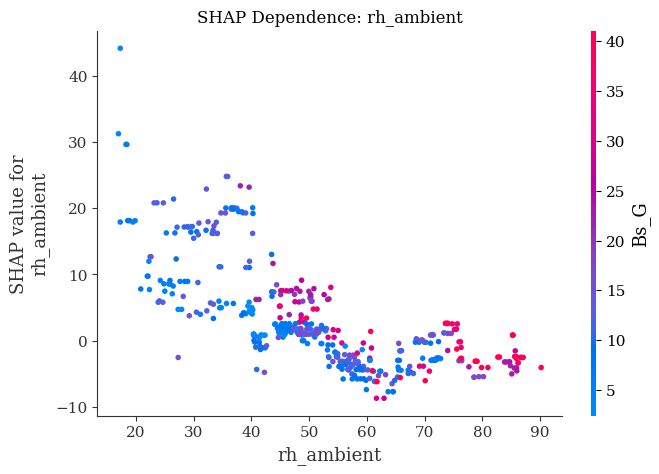

<Figure size 800x600 with 0 Axes>

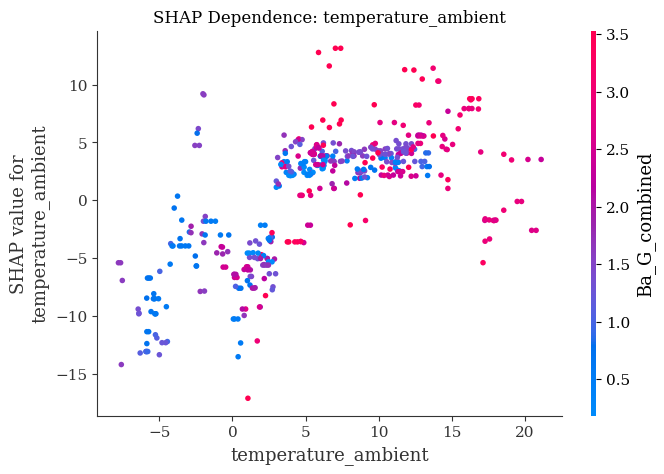

In [18]:
# 4.3 SHAP Values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary (Beeswarm)')
plt.savefig("/data/home/abhigyan/total_smokeshow/Results/SHAP_beeswarm.png")
plt.show()

# SHAP Dependence Plot (Example: Supersaturation)
# This shows how a specific feature interacts with others
features = ['dN_small', 'dN_medium', 'nitrate_CDCE', 'sulfate_CDCE', 'ammonium_CDCE', 'Ba_G_combined', 'Bs_G', 'AAE_BR', 'AE_BR', 'rh_ambient', 'temperature_ambient']

for feature in features:
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(feature, shap_values, X_test, interaction_index='auto', show=False)
    plt.title(f'SHAP Dependence: {feature}')
    plt.savefig(f"/data/home/abhigyan/total_smokeshow/Results/SHAP_dependence_{feature}.png")
    plt.show()